<a href="https://colab.research.google.com/github/deviramesh7310-dotcom/Yuva-Logistics-Task/blob/main/DataCo_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/DataCoSupplyChainDataset.csv.zip", compression='zip', encoding='latin1')

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 53


In [ ]:
# Dataset Overview
print("--- DATA HEAD ---")
display(df.head(3))

print("\n--- MISSING VALUES CHECK ---")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

--- DATA HEAD ---


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class



--- MISSING VALUES CHECK ---
Customer Lname              8
Customer Zipcode            3
Order Zipcode          155679
Product Description    180519
dtype: int64


In [ ]:
# Unnecessary fully-null / irrelevant column drop ചെയ്യുന്നു
if 'Product Description' in df.columns:
    df.drop(columns=['Product Description'], inplace=True)

# Missing values fill ചെയ്യുന്നു
df['Order Zipcode'] = df['Order Zipcode'].fillna(0)
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(0)
df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')

print("Data Cleaning Completed!")
print("Remaining Missing Values Count:", df.isnull().sum().sum())

Data Cleaning Completed!
Remaining Missing Values Count: 0


In [ ]:
# Key Performance Indicators (KPIs)
total_orders = len(df)
late_orders = (df['Late_delivery_risk'] == 1).sum()
on_time_orders = total_orders - late_orders

on_time_rate = (on_time_orders / total_orders) * 100
late_delivery_rate = (late_orders / total_orders) * 100

avg_shipping_days = df['Days for shipping (real)'].mean()
total_sales = df['Sales'].sum()
avg_profit = df['Order Profit Per Order'].mean()

print("--- LOGISTICS KPIs SUMMARY ---")
print(f"Total Orders: {total_orders}")
print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")
print(f"Late Delivery Rate: {late_delivery_rate:.2f}%")
print(f"Average Shipping Time: {avg_shipping_days:.2f} days")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Average Profit per Order: ${avg_profit:.2f}")

--- LOGISTICS KPIs SUMMARY ---
Total Orders: 180519
On-Time Delivery Rate: 45.17%
Late Delivery Rate: 54.83%
Average Shipping Time: 3.50 days
Total Sales: $36,784,735.01
Average Profit per Order: $21.97


/tmp/ipykernel_1109/2777327396.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Delivery Status', palette='Set2')


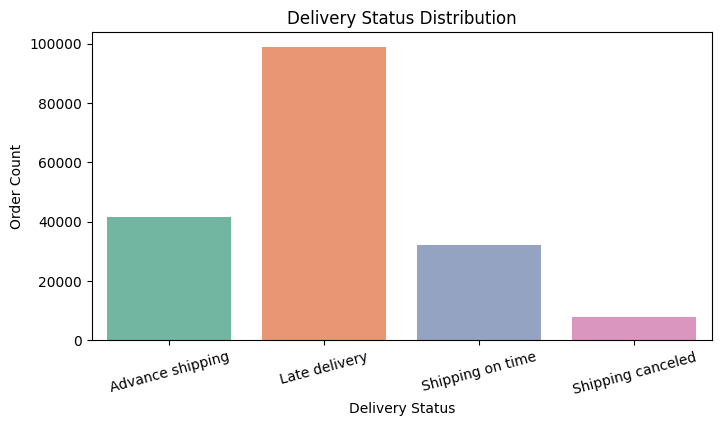

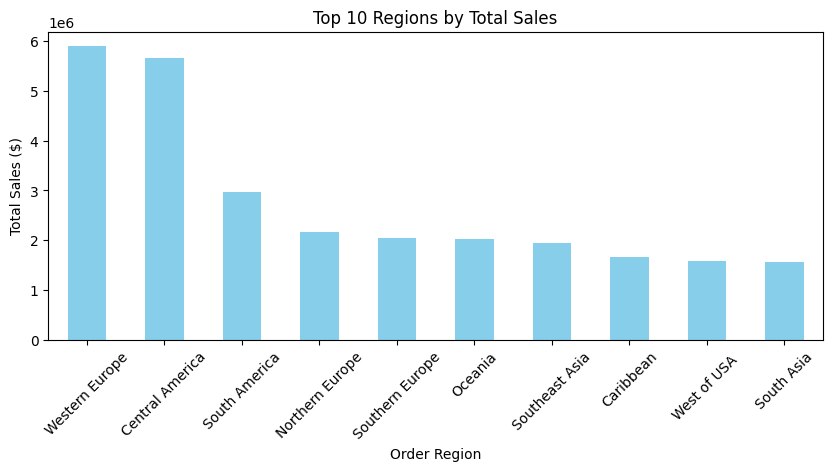

/tmp/ipykernel_1109/2777327396.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Shipping Mode', y='Late_delivery_risk', ci=None, palette='viridis')
/tmp/ipykernel_1109/2777327396.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Shipping Mode', y='Late_delivery_risk', ci=None, palette='viridis')


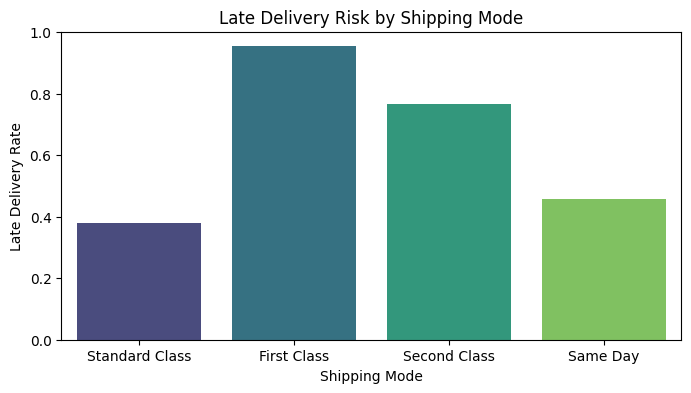

In [ ]:
# EDA Visualizations

# 1. Delivery Status Distribution
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Delivery Status', palette='Set2')
plt.title('Delivery Status Distribution')
plt.xlabel('Delivery Status')
plt.ylabel('Order Count')
plt.xticks(rotation=15)
plt.show()

# 2. Top 10 Regions by Total Sales
plt.figure(figsize=(10, 4))
top_regions = df.groupby('Order Region')['Sales'].sum().sort_values(ascending=False).head(10)
top_regions.plot(kind='bar', color='skyblue')
plt.title('Top 10 Regions by Total Sales')
plt.xlabel('Order Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.show()

# 3. Shipping Mode vs Late Delivery Risk
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Shipping Mode', y='Late_delivery_risk', ci=None, palette='viridis')
plt.title('Late Delivery Risk by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Late Delivery Rate')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Customer Level-ലേക്ക് Data Group ചെയ്യൽ
customer_df = df.groupby('Customer Id').agg({
    'Sales': 'sum',
    'Order Id': 'count',
    'Order Profit Per Order': 'mean'
}).rename(columns={'Order Id': 'Total_Orders', 'Order Profit Per Order': 'Avg_Profit'})

# Data Scaling (Standardization)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_df)

# K-Means Clustering Model (3 Groups/Clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(scaled_features)

print("--- CUSTOMER SEGMENTATION RESULT ---")
print(customer_df['Cluster'].value_counts())

--- CUSTOMER SEGMENTATION RESULT ---
Cluster
1    12444
0     8110
2       98
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features and Target selection
X = df[['Order Item Quantity', 'Product Price', 'Order Item Discount']]
y = df['Sales']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model Training
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- REGRESSION MODEL RESULTS ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

--- REGRESSION MODEL RESULTS ---
Mean Squared Error (MSE): 1258.25
R2 Score: 0.9274


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [ ]:
print(f"Original Dataset Shape: {df.shape}")

Original Dataset Shape: (180519, 52)


In [ ]:
# DATA CLEANING & IMPUTATION
# Drop completely missing column
if 'Product Description' in df.columns:
    df.drop(columns=['Product Description'], inplace=True)

# Impute missing categorical and postal attributes
df['Order Zipcode'] = df['Order Zipcode'].fillna(0)
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(0)
df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')

print(f"Remaining Missing Values: {df.isnull().sum().sum()}")

Remaining Missing Values: 0


In [ ]:
# STEP 3: OUTLIER DETECTION & HANDLING (IQR METHOD)
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping outliers in Sales
df['Sales_Cleaned'] = np.where(df['Sales'] > upper_bound, upper_bound,
                       np.where(df['Sales'] < lower_bound, lower_bound, df['Sales']))

In [ ]:
# Step 4: Data Normalization
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['Sales_Cleaned', 'Order Profit Per Order', 'Days for shipping (real)']])

print("Preprocessing Pipeline Executed Successfully!")

Preprocessing Pipeline Executed Successfully!
